<a href="https://colab.research.google.com/github/SoumajyotiDhut/rare-disease-identification-system/blob/main/Day_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

# Find your ZebraMap folder — adjust the path to match where it is in your Drive
zebramap_base = "/content/drive/MyDrive"

# List everything to find the folder name
for item in os.listdir(zebramap_base):
    print(item)

Classroom
Soumajyoti Dhut _13000222061_ITA
Moocs
Moocs_1st year
Colab Notebooks
13000222061_Soumajyoti Dhut_PEC-IT701C_CA1_ITA.pdf
13000222061_Soumajyoti Dhut_OEC-IT701A_CA1_ITA.pdf
13000222061_ITA.pdf
13000222061_Soumajyoti Dhut_OEC-IT701A.pdf
Dataset
Today photo 
Friends photos (pujo)
Data Analytics Assignment.xlsx
Soumajyoti_Resume.pdf
RareDiseaseProject
AppSeConnect_Resume.pdf
Resume_with_photo (1).pdf
Resume_with_photo.pdf
Resume.pdf
RESUME_1.pdf
rare_disease_project
Teleperformance_resume.pdf


In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os

zebramap_path = "/content/drive/MyDrive/rare_disease_project/data"

print("Contents of /data folder:")
for item in os.listdir(zebramap_path):
    full = os.path.join(zebramap_path, item)
    if os.path.isdir(full):
        count = len(os.listdir(full))
        print(f"  [DIR]  {item}/  ({count} items)")
    else:
        size = os.path.getsize(full) / (1024*1024)
        print(f"  [FILE] {item}  ({size:.1f} MB)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Contents of /data folder:
  [DIR]  zebramap/  (4 items)
  [DIR]  hpo/  (1 items)
  [DIR]  orphanet/  (0 items)
  [DIR]  multicare/  (0 items)
  [FILE] multimodal_samples.csv  (27.8 MB)
  [FILE] tiers.pkl  (0.0 MB)
  [FILE] dataset_analysis.png  (0.2 MB)
  [FILE] clean_multimodal_full.pkl  (17.2 MB)
  [DIR]  splits/  (8 items)
  [FILE] config.pkl  (0.0 MB)
  [FILE] label_encoder.pkl  (0.0 MB)
  [FILE] clean_tiers.pkl  (0.0 MB)
  [FILE] clean_multimodal_samples.csv  (26.9 MB)
  [FILE] label_encoder_image.pkl  (0.0 MB)


In [6]:
# Go inside each subfolder and report
for item in os.listdir(zebramap_path):
    full = os.path.join(zebramap_path, item)
    if os.path.isdir(full):
        print(f"\n--- {item}/ ---")
        sub_items = os.listdir(full)
        for s in sub_items[:10]:
            s_full = os.path.join(full, s)
            if os.path.isdir(s_full):
                count = len(os.listdir(s_full))
                print(f"  [DIR]  {s}/  ({count} items)")
            else:
                size = os.path.getsize(s_full) / (1024*1024)
                print(f"  [FILE] {s}  ({size:.1f} MB)")
        if len(sub_items) > 10:
            print(f"  ... and {len(sub_items)-10} more")


--- zebramap/ ---
  [FILE] augmented_disease_data.json  (9.4 MB)
  [FILE] structured_cases.json  (105.4 MB)
  [FILE] ZebraMap.json  (259.0 MB)
  [DIR]  images/  (1395 items)

--- hpo/ ---
  [FILE] phenotype.hpoa  (33.6 MB)

--- orphanet/ ---

--- multicare/ ---

--- splits/ ---
  [FILE] full_train.pkl  (18.2 MB)
  [FILE] full_test.pkl  (5.5 MB)
  [FILE] exp1_train.pkl  (0.5 MB)
  [FILE] exp3_train.pkl  (10.4 MB)
  [FILE] tier_a_train.pkl  (10.4 MB)
  [FILE] tier_a_test.pkl  (1.9 MB)
  [FILE] tier_c_train.pkl  (4.0 MB)
  [FILE] tier_c_test.pkl  (1.0 MB)


In [7]:
import pandas as pd
import pickle
import json

base = "/content/drive/MyDrive/rare_disease_project/data"

# 1. Look at the main multimodal CSV
print("=" * 50)
print("CLEAN MULTIMODAL CSV")
print("=" * 50)
df = pd.read_csv(f"{base}/clean_multimodal_samples.csv")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst row:")
print(df.iloc[0])
print(f"\nNull counts:\n{df.isnull().sum()}")

# 2. Look at tiers
print("\n" + "=" * 50)
print("TIERS")
print("=" * 50)
with open(f"{base}/clean_tiers.pkl", "rb") as f:
    tiers = pickle.load(f)
print(f"Type: {type(tiers)}")
print(f"Content preview: {str(tiers)[:300]}")

# 3. Look at exp1 split (your 5-10% data)
print("\n" + "=" * 50)
print("EXP1 TRAIN SPLIT (5-10%)")
print("=" * 50)
with open(f"{base}/splits/exp1_train.pkl", "rb") as f:
    exp1 = pickle.load(f)
print(f"Type: {type(exp1)}")
if hasattr(exp1, 'shape'):
    print(f"Shape: {exp1.shape}")
    print(f"Columns: {list(exp1.columns)}")
    print(f"Preview:\n{exp1.head(3)}")
else:
    print(f"Content: {str(exp1)[:300]}")

# 4. Label encoder
print("\n" + "=" * 50)
print("LABEL ENCODER")
print("=" * 50)
with open(f"{base}/label_encoder.pkl", "rb") as f:
    le = pickle.load(f)
print(f"Type: {type(le)}")
print(f"Number of classes: {len(le.classes_)}")
print(f"Sample classes: {list(le.classes_[:10])}")

CLEAN MULTIMODAL CSV
Shape: (36487, 9)

Columns: ['orpha_code', 'case_id', 'disease_name', 'symptoms', 'num_symptoms', 'images', 'num_images', 'age', 'gender']

First row:
orpha_code                                                    758
case_id                                            PMC11809835_01
disease_name                             Pseudoxanthoma elasticum
symptoms        ['progressive loss of vision', 'metamorphopsia...
num_symptoms                                                    8
images          [{'path': '/content/drive/MyDrive/rare_disease...
num_images                                                      4
age                                                            46
gender                                                     Female
Name: 0, dtype: object

Null counts:
orpha_code      0
case_id         0
disease_name    0
symptoms        0
num_symptoms    0
images          0
num_images      0
age             0
gender          0
dtype: int64

TIERS
Type: <class 'd

DATASET OVERVIEW
Total cases      : 36487
Unique diseases  : 1374
Avg symptoms/case: 8.5
Avg images/case  : 2.5

Top 10 most common diseases:
disease_name
Congenital anomaly of hepatic vein                 587
Diffuse large B-cell lymphoma                      496
Non-Hodgkin lymphoma                               493
CACH syndrome                                      479
Neuroendocrine neoplasm                            418
Microlissencephaly                                 414
Sarcoidosis                                        396
Amyloidosis                                        393
Nodular lymphocyte predominant Hodgkin lymphoma    393
Multiple myeloma                                   346

Bottom 10 rarest diseases:
disease_name
Distal duplication 2q syndrome                      1
Trisomy 12p syndrome                                1
Porencephaly                                        1
Complete atrioventricular septal defect             1
Nasopalpebral lipoma-coloboma syndrome

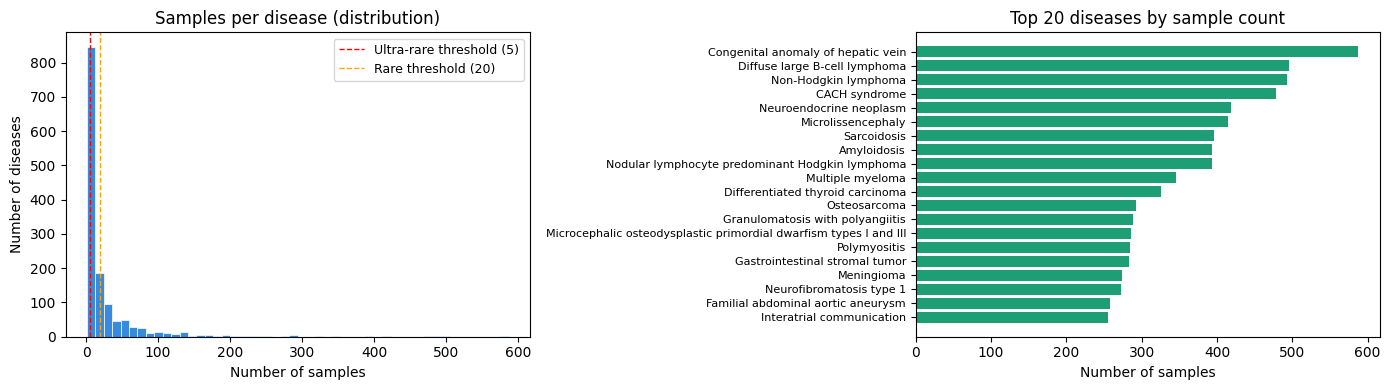


✓ Plot saved

IMAGE PATH CHECK
Image entry structure: {'path': '/content/drive/MyDrive/rare_disease_project/data/zebramap/images/758/PMC11809835/RomJOphthalmol-68-470-g001.jpg', 'type': 'Ophthalmology Imaging', 'subtype': 'Fundus Photography'}

Sample path: /content/drive/MyDrive/rare_disease_project/data/zebramap/images/758/PMC11809835/RomJOphthalmol-68-470-g001.jpg
File exists: True


In [8]:
import pandas as pd
import pickle
import json
import ast
import matplotlib.pyplot as plt

base = "/content/drive/MyDrive/rare_disease_project/data"

df = pd.read_csv(f"{base}/clean_multimodal_samples.csv")

# ── 1. Disease class distribution ──────────────────────────────
disease_counts = df['disease_name'].value_counts()

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total cases      : {len(df)}")
print(f"Unique diseases  : {df['disease_name'].nunique()}")
print(f"Avg symptoms/case: {df['num_symptoms'].mean():.1f}")
print(f"Avg images/case  : {df['num_images'].mean():.1f}")

print(f"\nTop 10 most common diseases:")
print(disease_counts.head(10).to_string())

print(f"\nBottom 10 rarest diseases:")
print(disease_counts.tail(10).to_string())

print(f"\nUltra-rare (<=5 cases) : {(disease_counts <= 5).sum()} diseases")
print(f"Rare (6-20 cases)      : {((disease_counts > 5) & (disease_counts <= 20)).sum()} diseases")
print(f"Common (>20 cases)     : {(disease_counts > 20).sum()} diseases")

# ── 2. Tier breakdown ──────────────────────────────────────────
with open(f"{base}/clean_tiers.pkl", "rb") as f:
    tiers = pickle.load(f)

print("\n" + "=" * 50)
print("TIER BREAKDOWN")
print("=" * 50)
for tier_name, codes in tiers.items():
    print(f"  {tier_name}: {len(codes)} diseases")

# ── 3. Exp1 split check ────────────────────────────────────────
with open(f"{base}/splits/exp1_train.pkl", "rb") as f:
    exp1 = pickle.load(f)

with open(f"{base}/splits/full_train.pkl", "rb") as f:
    full_train = pickle.load(f)

with open(f"{base}/splits/full_test.pkl", "rb") as f:
    full_test = pickle.load(f)

print("\n" + "=" * 50)
print("SPLITS SUMMARY")
print("=" * 50)
print(f"  exp1_train (5-10%) : {len(exp1)} samples")
print(f"  full_train         : {len(full_train)} samples")
print(f"  full_test          : {len(full_test)} samples")
print(f"  total              : {len(full_train) + len(full_test)} samples")

# ── 4. Plot class distribution ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution histogram
axes[0].hist(disease_counts.values, bins=50,
             color='#378ADD', edgecolor='white', linewidth=0.5)
axes[0].set_title('Samples per disease (distribution)', fontsize=12)
axes[0].set_xlabel('Number of samples')
axes[0].set_ylabel('Number of diseases')
axes[0].axvline(x=5, color='red', linestyle='--', linewidth=1, label='Ultra-rare threshold (5)')
axes[0].axvline(x=20, color='orange', linestyle='--', linewidth=1, label='Rare threshold (20)')
axes[0].legend(fontsize=9)

# Top 20 diseases bar chart
top20 = disease_counts.head(20)
axes[1].barh(range(len(top20)), top20.values, color='#1D9E75')
axes[1].set_yticks(range(len(top20)))
axes[1].set_yticklabels(top20.index, fontsize=8)
axes[1].set_title('Top 20 diseases by sample count', fontsize=12)
axes[1].set_xlabel('Number of samples')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f"{base}/dataset_analysis_day1.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Plot saved")

# ── 5. Image path check ────────────────────────────────────────
print("\n" + "=" * 50)
print("IMAGE PATH CHECK")
print("=" * 50)
sample_images = ast.literal_eval(df['images'].iloc[0])
print(f"Image entry structure: {sample_images[0]}")

import os
sample_path = sample_images[0]['path']
print(f"\nSample path: {sample_path}")
print(f"File exists: {os.path.exists(sample_path)}")

In [9]:
import json
import os
from datetime import datetime

base = "/content/drive/MyDrive/RareDiseaseProject/data"

summary = {
    "date": str(datetime.now().date()),
    "dataset": {
        "total_cases": 36487,
        "unique_diseases": 1374,
        "avg_symptoms_per_case": 8.5,
        "avg_images_per_case": 2.5
    },
    "class_distribution": {
        "ultra_rare_lte5": 582,
        "rare_6_to_20": 403,
        "common_gt20": 389
    },
    "tiers": {
        "tier_a": 88,
        "tier_b": 217,
        "tier_c": 1069
    },
    "splits": {
        "exp1_train_5pct": 514,
        "full_train": 18431,
        "full_test": 5339
    },
    "image_paths_valid": True,
    "image_structure": "orpha_code/PMC_id/filename.jpg",
    "status": "Day 1 complete"
}

os.makedirs(f"{base}/../results", exist_ok=True)
with open(f"{base}/../results/day1_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("=" * 50)
print("DAY 1 COMPLETE ✓")
print("=" * 50)
print(f"  Total cases        : 36,487")
print(f"  Diseases           : 1,374")
print(f"  Ultra-rare targets : 582 diseases → GAN augmentation")
print(f"  Exp1 split ready   : 514 samples")
print(f"  Full train ready   : 18,431 samples")
print(f"  Image paths        : ✓ verified")
print(f"\n  Summary saved to results/day1_summary.json")
print(f"\n  Next → Day 2: Baseline NLP model on exp1_train (514 samples)")

DAY 1 COMPLETE ✓
  Total cases        : 36,487
  Diseases           : 1,374
  Ultra-rare targets : 582 diseases → GAN augmentation
  Exp1 split ready   : 514 samples
  Full train ready   : 18,431 samples
  Image paths        : ✓ verified

  Summary saved to results/day1_summary.json

  Next → Day 2: Baseline NLP model on exp1_train (514 samples)


In [10]:
import json
import os
from datetime import datetime

base = "/content/drive/MyDrive/rare_disease_project"
os.makedirs(f"{base}/results", exist_ok=True)

# Master results tracker — both Kaggle and Colab will update this
tracker = {
    "project": "Rare Disease Identification System",
    "last_updated": str(datetime.now().date()),
    "experiments": {
        "exp1_baseline_scarcity": {
            "platform": "Kaggle",
            "dataset": "HAM10000 + Symptom CSV",
            "status": "pending",
            "metrics": {}
        },
        "exp2_gan_augmented": {
            "platform": "Kaggle",
            "dataset": "HAM10000 + Symptom CSV",
            "status": "pending",
            "metrics": {}
        },
        "exp3_full_upperbound": {
            "platform": "Kaggle",
            "dataset": "HAM10000 + Symptom CSV",
            "status": "pending",
            "metrics": {}
        },
        "exp4_zebramap_baseline": {
            "platform": "Colab",
            "dataset": "ZebraMap",
            "status": "pending",
            "metrics": {}
        },
        "exp5_zebramap_gan": {
            "platform": "Colab",
            "dataset": "ZebraMap",
            "status": "pending",
            "metrics": {}
        },
        "fusion_multimodal": {
            "platform": "Colab",
            "dataset": "ZebraMap",
            "status": "pending",
            "metrics": {}
        }
    }
}

with open(f"{base}/results/experiment_tracker.json", "w") as f:
    json.dump(tracker, f, indent=2)

print("✓ Experiment tracker created")
print(f"  Location: {base}/results/experiment_tracker.json")
print(f"\n  Kaggle handles : Exp 1, 2, 3 (HAM10000)")
print(f"  Colab handles  : Exp 4, 5, Fusion (ZebraMap)")
print(f"\n  Ready for Day 2 →")

✓ Experiment tracker created
  Location: /content/drive/MyDrive/rare_disease_project/results/experiment_tracker.json

  Kaggle handles : Exp 1, 2, 3 (HAM10000)
  Colab handles  : Exp 4, 5, Fusion (ZebraMap)

  Ready for Day 2 →
